1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


2.1 Creating Datasets

In [2]:
# Generate 2000 non-linear samples
X, y = make_moons(
    n_samples=2000,
    noise=0.12,
    random_state=42
)

# Create DataFrame in the same format as your image
df = pd.DataFrame({
    'X': X[:, 0],
    'Y': X[:, 1],
    'Class': y.astype(float)
})

df.head()

,X,Y,Class
0,1.750613,0.215969,1.0
1,0.388455,0.937320,0.0
2,0.494370,-0.308781,1.0
3,-0.947407,0.137360,0.0
4,0.504882,-0.348035,1.0


2.2 Visualize the Dataset

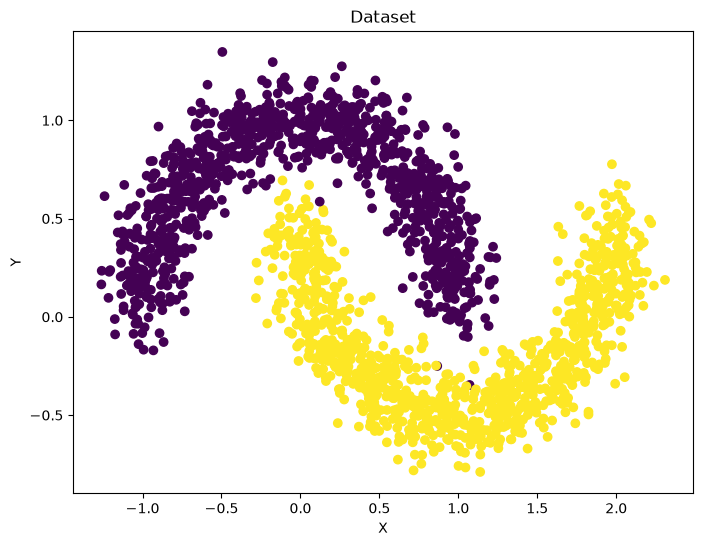

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['X'],
    df['Y'],
    c=df['Class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset')
plt.show()

3. Separate Features and Target

In [4]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 2)
y shape: (2000,)


4. Create Neural Network with ReLU

In [6]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

5. Model Summary

In [7]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

6. Check Initial Weights

In [8]:
model.get_weights()

[array([[-1.9533477 ,  0.82774717,  1.7354897 , -0.63300395,  1.7606686 ,
         -0.20805936, -0.17216313, -0.35704342, -2.1071813 ,  1.3951812 ],
        [-1.0889317 , -0.8469385 , -0.9860005 , -1.9778775 , -0.13056262,
         -0.7592491 , -0.19072768, -0.41670617,  0.3766898 , -0.6158468 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.2909857 ,  0.35980052, -0.13665701,  0.05131214, -0.89332   ,
          0.46197093,  0.47237548,  0.08799847,  0.4965188 , -0.46817458],
        [-0.30141547, -0.43589577, -0.26470152,  0.6618005 ,  0.26495555,
         -0.20767084, -0.20985599, -0.06620368, -0.03935573,  0.10530324],
        [-0.27030787, -0.06361841, -0.04799433,  0.07200572,  0.05119389,
         -0.9554088 , -0.30224872,  0.50110775,  0.33261657,  0.18954317],
        [ 0.71832806,  0.07746143,  0.2333792 , -0.33361647,  0.01959571,
         -0.04191361, -0.15451133,  0.10802031, -0.33764374, -0.06372664],
        [ 0.62749

7. Store the Weights

In [9]:
initial_weights = model.get_weights()

8. Random Weight Initialization with Zero Bias Initialization

In [10]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

9. Set the Initialized Weights and Biases in the Model

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[ 1.4008887 , -0.55301833, -0.17959295,  1.118989  ,  0.6174361 ,
         -0.12040766,  0.20008345, -0.35784042, -0.09546875,  0.79954576],
        [-0.09762086,  0.58221143,  1.4815421 ,  0.5895185 , -0.2331982 ,
         -0.47920302, -0.6302962 ,  1.2105286 ,  0.10296421, -1.0619754 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.27125278, -0.10170622, -0.06654099, -0.3254137 ,  0.26841012,
          0.38717747, -0.56636584, -0.18666352,  0.05931258,  0.03503768],
        [ 0.29482353, -0.50145775,  0.7473507 , -0.22656013, -0.13479286,
          0.20277281, -0.0580912 ,  0.61409104,  0.03391294, -0.28769445],
        [-0.39679965,  0.22365853, -0.19824126, -0.05779124,  0.221047  ,
         -0.25813934,  0.51562566,  0.22370951,  0.23216304,  0.7263979 ],
        [-0.01456726, -0.08609386, -0.14475133, -0.07040128,  0.23232493,
         -0.42506474, -0.00809729, -0.14281508, -0.1342639 , -0.07272778],
        [-0.54187

10. Compile the Model

In [13]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

11. Train the Model

In [14]:
history = model.fit(
    X,
    y,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7694 - loss: 0.6336 - val_accuracy: 0.7850 - val_loss: 0.5630
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8075 - loss: 0.4875 - val_accuracy: 0.8400 - val_loss: 0.3833
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8506 - loss: 0.3414 - val_accuracy: 0.8675 - val_loss: 0.2917
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8712 - loss: 0.2871 - val_accuracy: 0.8825 - val_loss: 0.2591
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8731 - loss: 0.2691 - val_accuracy: 0.8900 - val_loss: 0.2431
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8800 - loss: 0.2505 - val_accuracy: 0.8900 - val_loss: 0.2296
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8806 - loss: 0.2363 - val_accuracy: 0.9000 - val_loss: 0.2126
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8894 - loss: 0.2217 - val_accuracy: 0.9125 - v

12. Check the Weights After Training

In [15]:
model.get_weights()

[array([[ 1.6549914 , -1.1328446 , -0.15443566,  1.0488932 ,  0.6836351 ,
         -0.45852134,  0.43553478, -0.21452683, -0.6916124 ,  0.8333161 ],
        [ 0.15172318,  0.89797044,  1.3517998 ,  0.4029586 ,  0.05897896,
         -0.4377323 , -0.47273496,  1.058695  , -0.1481455 , -1.1767044 ]],
       dtype=float32),
 array([-0.42496178, -0.12568915,  0.5492705 ,  0.32248184, -0.47368258,
         0.44572172, -0.21914066,  0.40987217,  0.69101894,  0.469519  ],
       dtype=float32),
 array([[ 2.4879317e-01, -8.0331638e-02,  3.8315934e-01, -4.8191115e-01,
          4.8204899e-01,  5.8662933e-01, -7.2731262e-01, -1.5145554e-01,
          2.0022881e-01, -7.9711251e-02],
        [ 8.2023865e-01, -3.3455101e-01,  1.3811663e+00,  3.0572850e-01,
         -3.7694636e-01,  3.5216972e-01, -4.5857873e-02,  9.2812657e-01,
          3.1624135e-01, -1.6935301e-01],
        [-2.5170180e-01,  3.0363572e-01,  8.9322604e-02, -5.5869360e-02,
          1.3114044e-01, -1.5186490e-01,  6.5588903e-01,  3

13. Check the Predictions

In [16]:
predictions = model.predict(X, verbose=0)

predictions[:10]

array([[9.9998450e-01],
       [3.9164793e-06],
       [9.9999994e-01],
       [3.8139436e-10],
       [9.9999994e-01],
       [1.0000000e+00],
       [4.3787340e-10],
       [9.9999917e-01],
       [1.1025293e-04],
       [9.9999988e-01]], dtype=float32)

14. Plot Training Loss

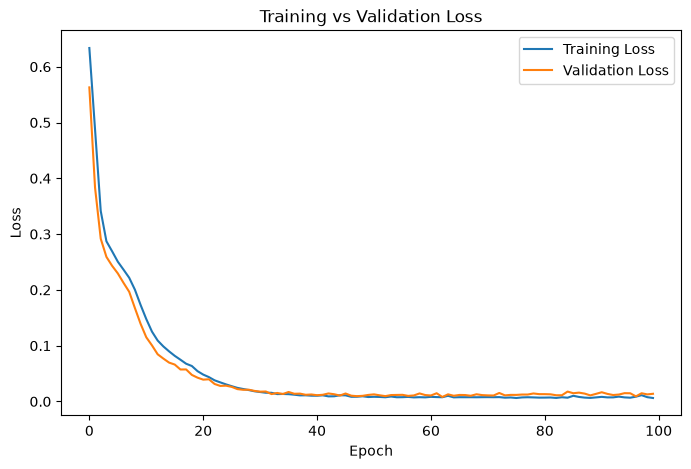

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

15. Plot Accuracy

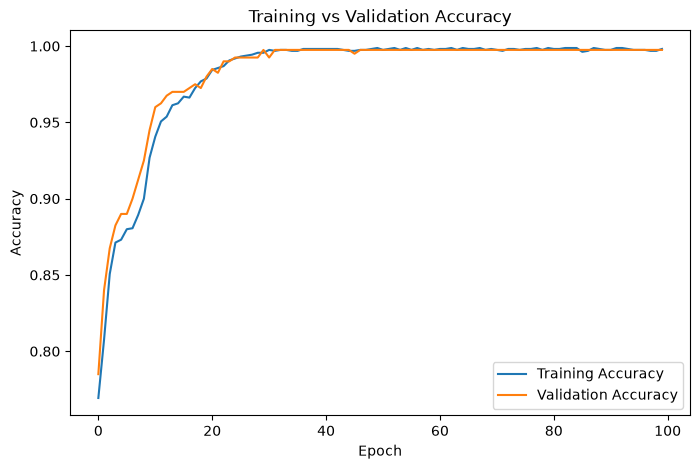

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

16. Decision Boundary

In [19]:
from mlxtend.plotting import plot_decision_regions

class MyModel:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(
            X,
            verbose=0
        )

        return (
            pred >= 0.5
        ).astype(int).ravel()

17. Create Classifier

In [20]:
clf = MyModel(model)

18. Plot Decision Regions

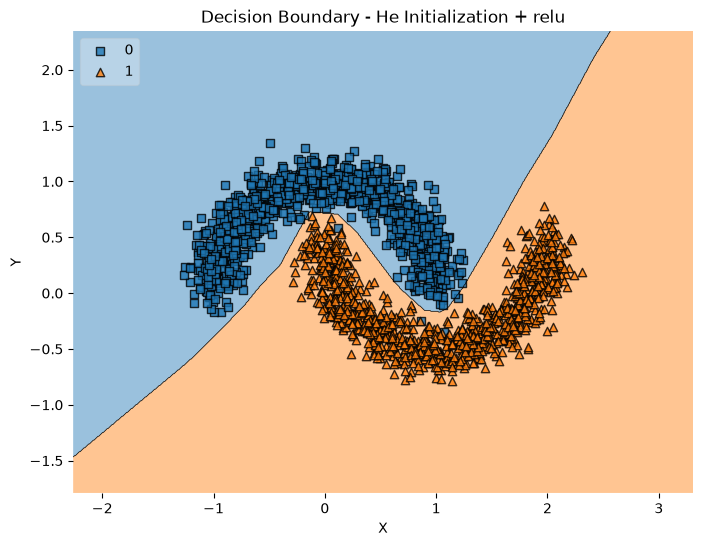

In [22]:
plt.figure(figsize=(8, 6))

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Boundary - He Initialization + relu')

plt.show()

In [23]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.023044062696165088)

In [24]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.022471018457553837)